# This report concerns the relationship between sleep and the allocation of time.

- In their article, Biddle and Hamermesh study sleep as an economic choice affected primarly by work, wages, and individual characteristics.

- The key idea is that higher wage rates may reduce sleep time among men, because a higher wage increases the opportunity cost of time spent sleeping. However, the wage variable creates an econometric problem; it is missing for individuals who do not work and may also be endogenous.

- The aim of this report is to examine and estimate a statistical model for sleep time as well as the limitations caused by missing wage data and possible endogeneity.

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [31]:
column_names = [
    "age_years",
    "is_black",
    "case_id",
    "is_clerical_worker",
    "is_construction_worker",
    "education_years",
    "earnings_1974",
    "good_health",
    "in_labor_force",
    "leisure_excl_naps",
    "leisure_incl_naps",
    "leisure_relaxation",
    "lives_in_smsa",
    "log_hourly_wage",
    "log_other_income",
    "is_male",
    "is_married",
    "is_protestant",
    "relaxation_total",
    "is_self_employed",
    "sleep_minutes",
    "sleep_naps_minutes",
    "lives_in_south",
    "spouse_wage_income",
    "spouse_works",
    "work_minutes",
    "union_member",
    "main_job_minutes",
    "second_job_minutes",
    "experience_years",
    "has_young_child",
    "years_married",
    "hourly_wage",
    "age_squared",
]

# note: I'm using modified column names, not the exact names from the dataset description file, for improved readability

df = pd.read_excel("sleep75.xls", header=None, names=column_names, na_values=".")


print(df.head(5))
print(df.shape)
print(df.info())
print(df.describe())

   age_years  is_black  case_id  is_clerical_worker  is_construction_worker  \
0         32         0        1                 0.0                     0.0   
1         31         0        2                 0.0                     0.0   
2         44         0        3                 0.0                     0.0   
3         30         0        4                 0.0                     0.0   
4         64         0        5                 0.0                     0.0   

   education_years  earnings_1974  good_health  in_labor_force  \
0               12              0            0               1   
1               14           9500            1               1   
2               17          42500            1               1   
3               12          42500            1               1   
4               14           2500            1               1   

   leisure_excl_naps  ...  spouse_works  work_minutes  union_member  \
0               3529  ...             0          3438    

In [32]:
print(df.isna().sum())

print(df["hourly_wage"].isna().sum())

print(df[df["in_labor_force"] == 0].isna().sum().sum() / 2)

# This is a check for IF the missing values are for sure only happening in people not in the labor force.

age_years                   0
is_black                    0
case_id                     0
is_clerical_worker          0
is_construction_worker      0
education_years             0
earnings_1974               0
good_health                 0
in_labor_force              0
leisure_excl_naps           0
leisure_incl_naps           0
leisure_relaxation          0
lives_in_smsa               0
log_hourly_wage           174
log_other_income            0
is_male                     0
is_married                  0
is_protestant               0
relaxation_total            0
is_self_employed            0
sleep_minutes               0
sleep_naps_minutes          0
lives_in_south              0
spouse_wage_income          0
spouse_works                0
work_minutes                0
union_member                0
main_job_minutes            0
second_job_minutes          0
experience_years            0
has_young_child             0
years_married               0
hourly_wage               174
age_square

Overall, we can observe as much as 174 missing values all concerning hourly wages.

This will be our main concern in modelling this dataset, because wage is not missing at random.

The missing values are **only** spread among individuals who are not in the labor force.

This confirms that wage missingness is missing **not** at random

Hence, I decide not use simple median imputation for wage, for the reason that data is missing for a systematic economic reason, not because of random measurement failure. 

Imputing the average or median wage for nonworkers would create artificial wage values and would blur the distinction between workers and nonworkers.

Therefore, dropping all observations with missing wage would remove nonworkers from the sample and change the analysis from the full population to labor force participants only.

For this reason, I'm going to use two separate models;

The main model will be estimated on the full sample and will exclude wage, while including an indicator for labor-force participation.

The second model will be estimated only for individuals in the labor force and will include hourly wage (or its logarithm).
This model will be treated as a secondary specification, useful for examining the wage and sleep relationship among workers only.

Though I'm obliged to mention that its results will not describe the full sample.

# First, manual analysis of the dataset

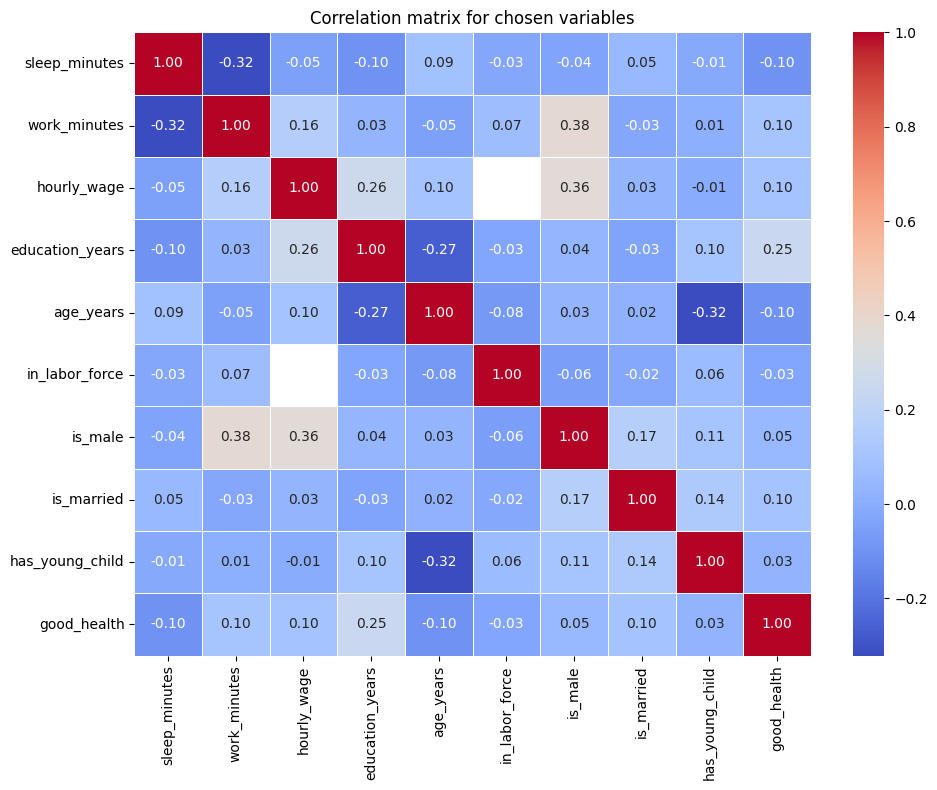

In [ ]:
main_vars = [
    "sleep_minutes",
    "work_minutes",
    "hourly_wage",
    "education_years",
    "age_years",
    "in_labor_force",
    "is_male",
    "is_married",
    "has_young_child",
    "good_health",
]

# these variables have been chosen by hand to serve for some introductory analysis

corr_matrix = df[main_vars].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation matrix for chosen variables")
plt.tight_layout()
plt.show()

At first, moderate negative correlaton can be observed between sleep time in minutes and work time in minutes. This could possibly be worth looking into, as it might explain the opportunity cost between working and sleeping.

Next up, having a child as well as education are negatively correlated with age. This seems to be rather self explanatory as a social phenomenon.

When it comes to positive correlation, being a male has a mild positive correlation with both work time in minutes and hourly wage. I would find a source of this correlaton in the socio-economic circumstances of the year this sample was gathered in. This may reflect the socio-economic circumstances of the 1975 sample, when male labor-force participation and earnings were often higher due to traditional household roles and gender inequality in the labor market.

Another positive correlation is education in years to hourly wage, this might be supported by the overall idea that higher educated people tend to earn slightly more.

For the purpose of this report, the correlation analysis will be treated as an exploratory step rather than as formal evidence of causality. The observed correlations help identify relationships that are worth investigating further, especially the negative relationship between work time and sleep time. However, correlation does not control for other factors and does not account for the structural missingness of wages.

Therefore, the next step is to estimate regression models that control for several variables at once. First, a simple two-variable model will be estimated to examine the basic relationship between work time and sleep time.

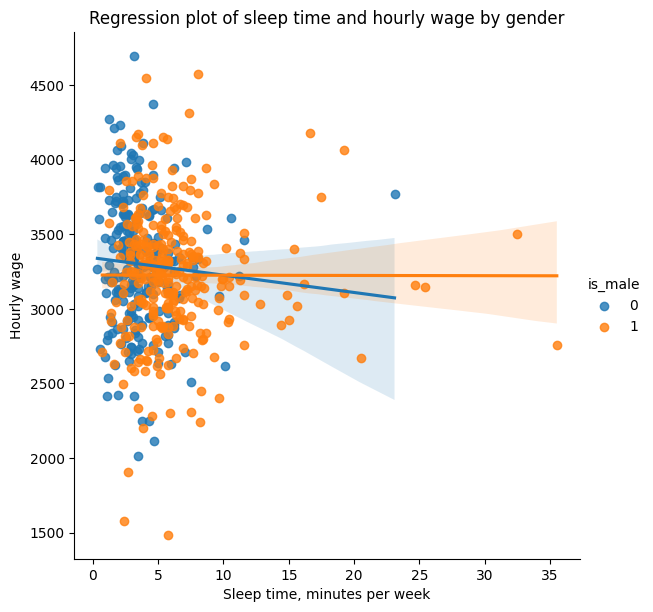

In [72]:
sns.lmplot(
    data=df,
    x="hourly_wage",
    y="sleep_minutes",
    hue="is_male",
    height=6,
)

plt.title("Regression plot of sleep time and hourly wage by gender")
plt.xlabel("Sleep time, minutes per week")
plt.ylabel("Hourly wage")
plt.show()

1. The relationship between sleep time and hourly wage seems weak and the regression line is almost flat for men.

2. For woman, the line is slightly negative, which means that higher sleep time is mildly correlated with the hourly wage.

3. A clear gender wage difference can be observed, which is supported by earlier observation.

4. High-wage outliers are present, which might suggest that a transformation could be useful.

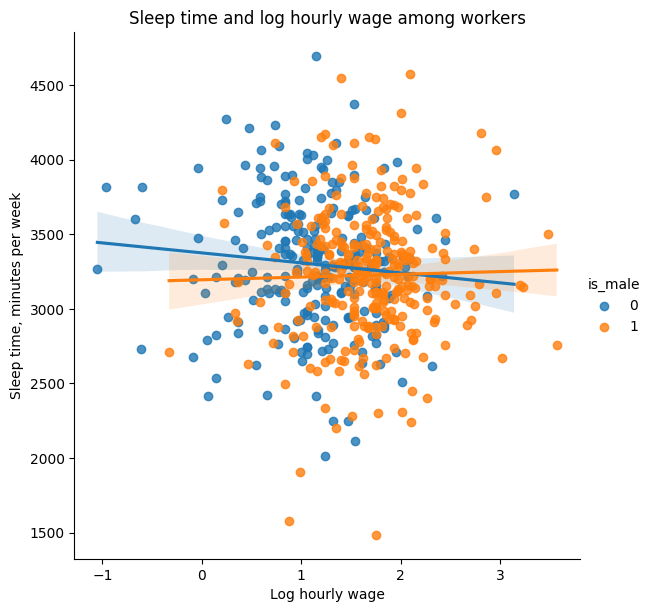

In [73]:
workers_only = df[df["in_labor_force"] == 1].copy()

sns.lmplot(
    data=workers_only,
    x="log_hourly_wage",
    y="sleep_minutes",
    hue="is_male",
    height=6,
)

plt.title("Sleep time and log hourly wage among workers")
plt.xlabel("Log hourly wage")
plt.ylabel("Sleep time, minutes per week")
plt.show()

The points are widely scattered, which suggests that wage alone can only explain very little of the variation in sleep time.

Most workers sleep somewhere around 3,000–3,600 minutes per week, regardless of wage level.

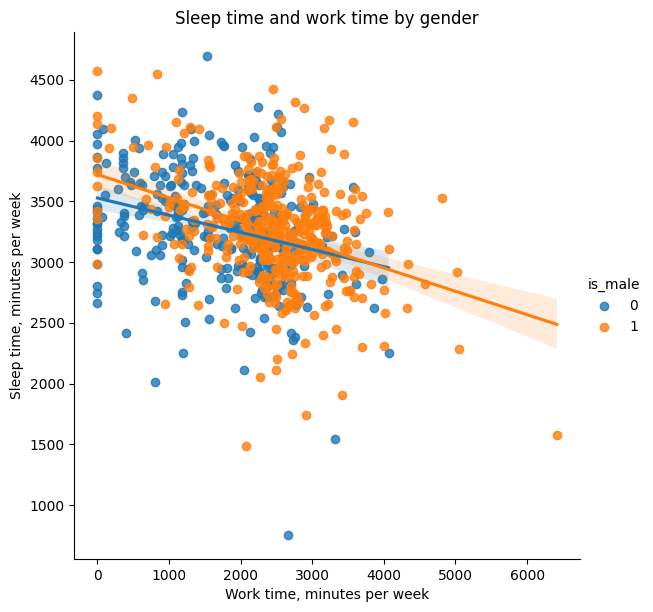

In [74]:
sns.lmplot(
    data=df,
    x="work_minutes",
    y="sleep_minutes",
    hue="is_male",
    height=6,
)

plt.title("Sleep time and work time by gender")
plt.xlabel("Work time, minutes per week")
plt.ylabel("Sleep time, minutes per week")
plt.show()

The plot for sleep time and work time shows a clear negative relationship between weekly work time and weekly sleep time. People who work more minutes per week naturally tend to sleep less, which is a notable tradeoff.

This pattern is visible for both men and women, although men are more concentrated at higher levels of work time. Compared with the wage plot, work time appears to have a much stronger relationship with sleep, so it should be a key variable in the regression models.

In [75]:
simple_model = smf.ols("sleep_minutes ~ work_minutes", data=df).fit(cov_type="HC1")

print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:          sleep_minutes   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     65.69
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.34e-15
Time:                        22:39:35   Log-Likelihood:                -5267.1
No. Observations:                 706   AIC:                         1.054e+04
Df Residuals:                     704   BIC:                         1.055e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3586.3770     41.982     85.427   

This simple regression model shows a statistically significant negative relationship between weekly work time and weekly sleep time. The estimated cofficient of `work_minutes` is -0.1507, meaning that one additional minute of work per week is associated with about 0.15 less minutes of sleep per week. (For one additinal hour of work per week it is about 9 less minutes of sleep.)


$60 \times (-0.1507) \approx -9.04$


The coefficient is statistically significant, suggesting that the negative relationship observed in the exploratory plot is also present in the regression model. However, the R-squared is 0.103, meaning that the work time alone is able to explain just about 10.3% of the variation in sleep time. Therefore, this model might be useful as a benchmark but is too simple and leaves a almost 90% of the dependancy a mystery.

In [76]:
model_full = smf.ols(
    "sleep_minutes ~ work_minutes + education_years + age_years + age_squared + "
    "is_male + is_married + has_young_child + good_health + in_labor_force",
    data=df
).fit(cov_type="HC1")

print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:          sleep_minutes   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     9.869
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           2.57e-14
Time:                        22:47:12   Log-Likelihood:                -5258.1
No. Observations:                 706   AIC:                         1.054e+04
Df Residuals:                     696   BIC:                         1.058e+04
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        3818.4766    268.356     